In [ ]:
#hide
#skip
! [ -e /content ] && pip install -Uqq fastai  # upgrade fastai on colab

     |████████████████████████████████| 186 kB 9.9 MB/s 
     |████████████████████████████████| 56 kB 4.9 MB/s 


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = Path('/content/gdrive/MyDrive/DATASET/Spectrogram/Train')


In [ ]:
tfms = aug_transforms(flip_vert=False,size=(150,150))


In [ ]:
np.random.seed(42)
data = ImageDataLoaders.from_folder(path,test='/content/gdrive/MyDrive/DATASET/Spectrogram/Test', ds_tfms=tfms,valid_pct=0.25,bs=32,num_workers=4)

In [ ]:
learn = cnn_learner(data, res ,metrics=[accuracy,error_rate])

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


  0%|          | 0.00/83.3M [00:00<?, ?B/s]

/usr/local/lib/python3.7/dist-packages/torch/nn/functional.py:718: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at  /pytorch/c10/core/TensorImpl.h:1156.)
  return torch.max_pool2d(input, kernel_size, stride, padding, dilation, ceil_mode)


In [ ]:
learn.unfreeze()


In [ ]:
print(learn.summary())

Sequential (Input shape: 32)
Layer (type)         Output Shape         Param #    Trainable 
                     32 x 64 x 75 x 75   
Conv2d                                    9408       True      
BatchNorm2d                               128        True      
ReLU                                                           
MaxPool2d                                                      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
Conv2d                                    36864      True      
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      True      
BatchNorm2d                      

In [ ]:
learn.fit_one_cycle (n_epoch=20 ,lr_max = 0.0001 )

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,2.753657,1.873798,0.317766,0.682234,14:09
1,1.614507,0.975925,0.651404,0.348596,00:39
2,0.690114,0.425962,0.853175,0.146825,00:39
3,0.356415,0.333353,0.887363,0.112637,00:39
4,0.228129,0.235908,0.924603,0.075397,00:39
5,0.191538,0.134637,0.960623,0.039377,00:39
6,0.135908,0.067235,0.977106,0.022894,00:39
7,0.093541,0.103864,0.963065,0.036935,00:39
8,0.043801,0.083490,0.976496,0.023504,00:39
9,0.050146,0.101738,0.969170,0.030830,00:39


In [ ]:
interp = ClassificationInterpretation.from_learner(learn)


In [ ]:
interp.print_classification_report()

              precision    recall  f1-score   support

   Chahargah       0.99      0.98      0.99       599
    Homayoun       1.00      1.00      1.00       447
      Mahour       0.98      0.99      0.99       584
        Nava       0.99      1.00      1.00       383
 Rastpanjgah       0.99      1.00      0.99       394
       Segah       1.00      0.98      0.99       388
       Shour       0.99      1.00      0.99       481

    accuracy                           0.99      3276
   macro avg       0.99      0.99      0.99      3276
weighted avg       0.99      0.99      0.99      3276



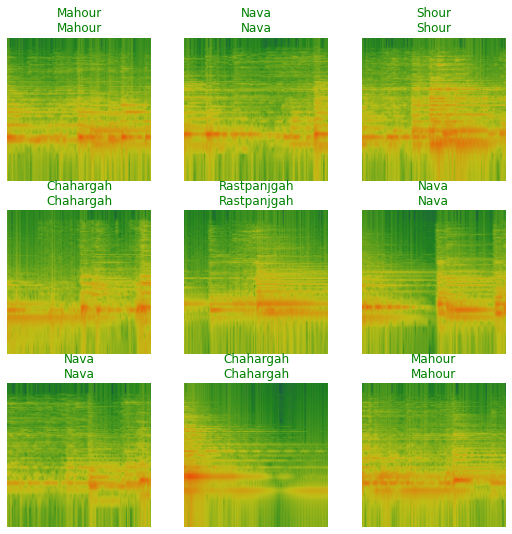

In [ ]:
learn.show_results()


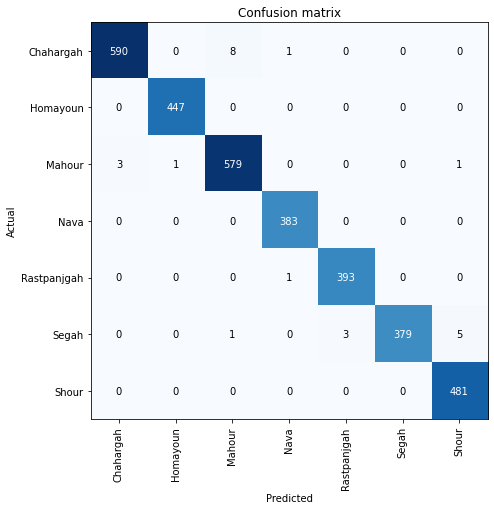

In [ ]:
interp.plot_confusion_matrix(figsize=(7,7))

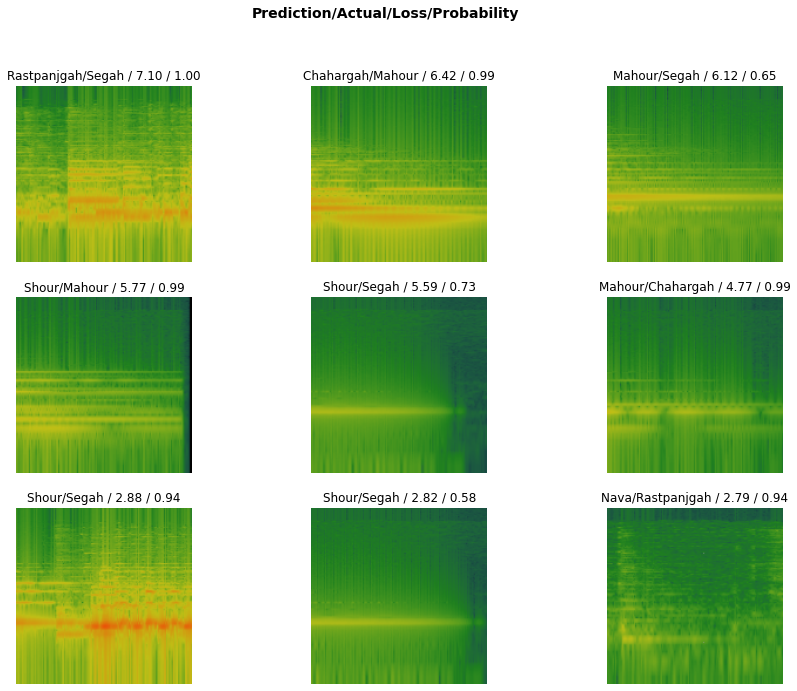

In [ ]:
interp.plot_top_losses(9, figsize=(15,11))

In [ ]:
interp.most_confused(min_val=2)


[('Chahargah', 'Mahour', 8),
 ('Segah', 'Shour', 5),
 ('Mahour', 'Chahargah', 3),
 ('Segah', 'Rastpanjgah', 3)]